# NeuralProphet - Modelo Aplicado a demanda energética Alemania
hacer modelo SARIMA, en dicho apartado hacer la validación con la ACF y la PACF, periodograma y demas


In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere

import os
os.environ["PYTHONHASHSEED"] = "42"

import random
random.seed(42)

import numpy as np
np.random.seed(42)

import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# procesamiento
import pandas as pd
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from neuralprophet import NeuralProphet, set_log_level
# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere
from statsmodels.graphics.tsaplots import acf, pacf
# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna
from scipy.signal import periodogram



c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


Se cargan los valores de consumo a nivel semanal. La semana en este caso se toma el primer día como lunes, es fecha muestra el promedio de la semana y se formatean las fechas en formato date. El orden de las observaciones es de $10^6$

In [2]:
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se renombran las columnas de la siguiente forma:
- Start date: ds
- value: y

Según documentación oficial

In [3]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
#df_data_close["Date"] = pd.to_datetime(df_data_close["Date"])
#df_data_close["Date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
#df_data_close = df_data_close.set_index("Date")
df_data_close = df_data_close.rename(columns={
    "Start date": "ds",
    "value": "y"
})
df_data_close.head()


,ds,y
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


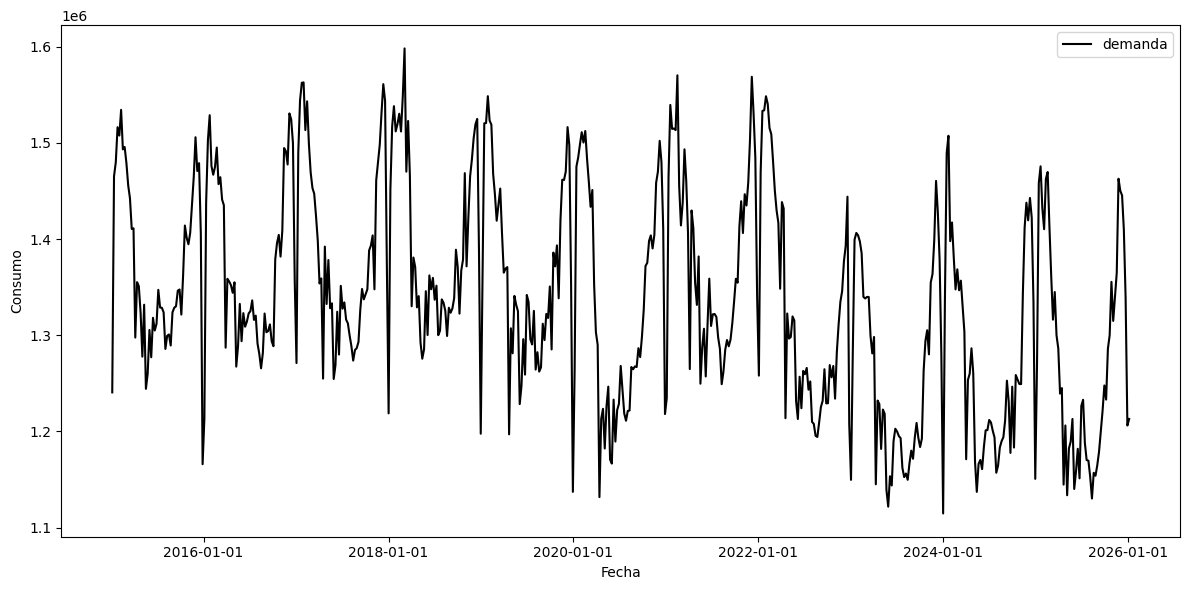

In [4]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["ds"], df_data_close["y"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [5]:
# partición temporal
percentage = 0.9
folds_data_size = int(len(df_data_close) * percentage)
folds_data = df_data_close.iloc[:folds_data_size]
val_data = df_data_close.iloc[folds_data_size:]
start_val_data = val_data["ds"].values[0]

print(start_val_data)

2024-12-02T00:00:00.000000000


gráfica folds/val

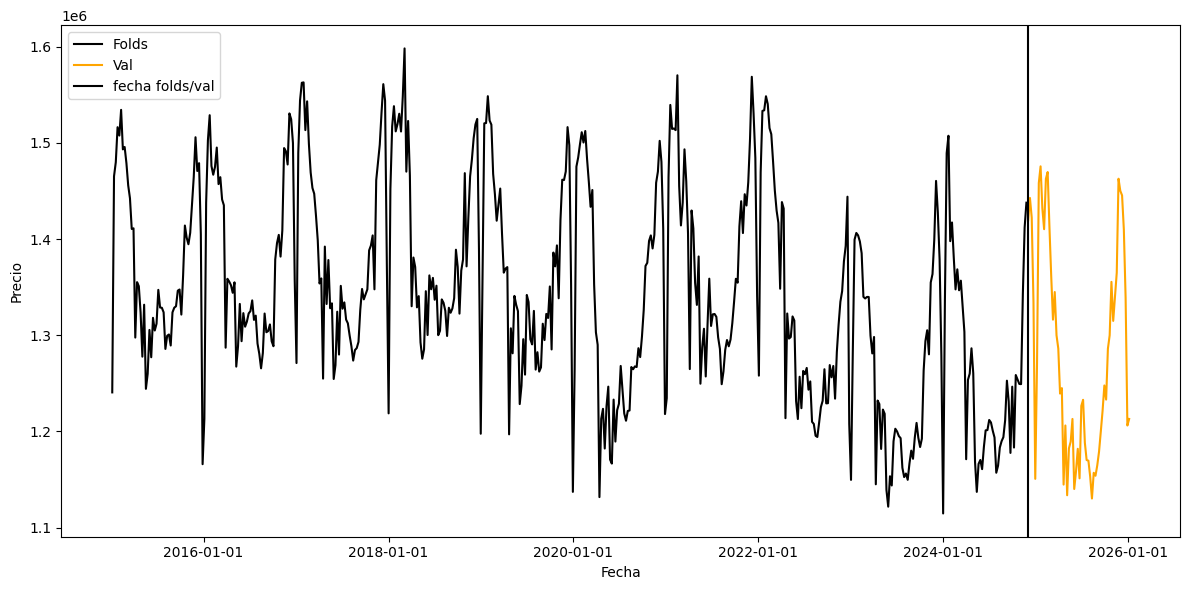

In [6]:
# se grafican los datos folds/val
plt.figure(figsize=(12,6))
plt.plot(folds_data["ds"], folds_data["y"], label="Folds", color="black")
plt.plot(val_data["ds"], val_data["y"], label="Val", color="orange")
plt.axvline(start_val_data, label="fecha folds/val", color="black")
#plt.plot(val_data.index, val_data["NVDA_log_diff"], label="Serie Transformada", color="orange")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [7]:
print(len(folds_data))
print(len(val_data))

517
58


ADF Statistic: -5.1166898303901229
p-value: 0.0000129751898812
Estacionaria


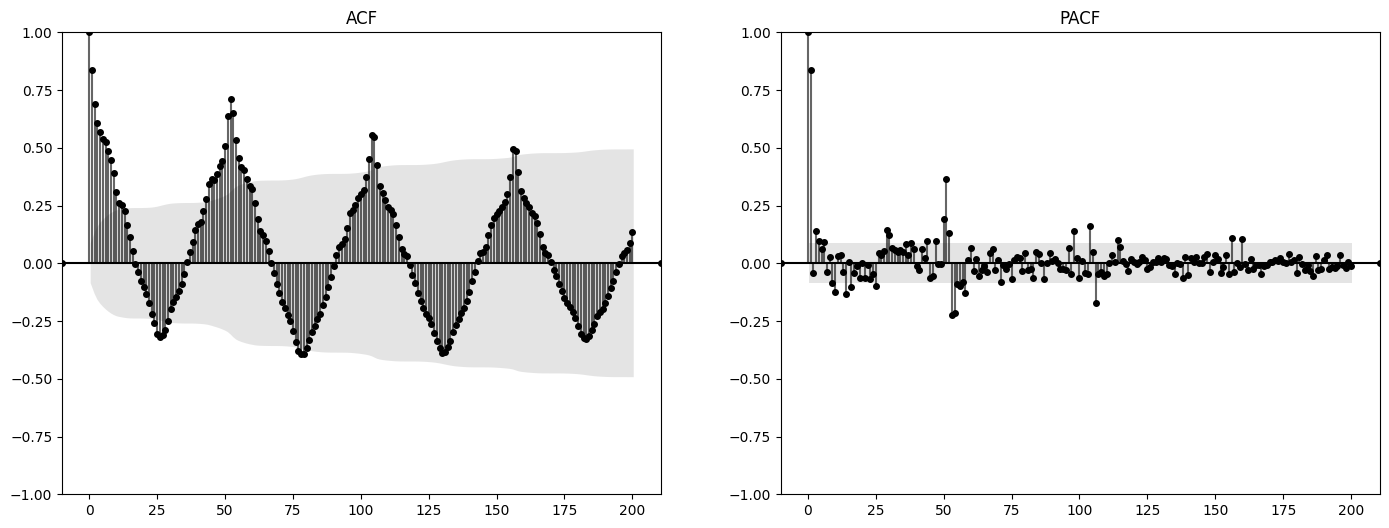

In [8]:
def check_stationarity(ts):
    result = adfuller(ts, autolag='AIC')
    p_value = result[1]
    print(f"ADF Statistic: {result[0]:.16f}")
    print(f"p-value: {p_value:.16f}")
    print('Estacionaria' if p_value < 0.05 else 'No estacionaria')

def plot_acf_pacf(ts, n_lags=200, title_graph=["ACF", "PACF"]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,6))

    plot_acf(
        ts,
        ax=ax1,
        lags=n_lags,
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4,
        title=title_graph[0]
    )

    plot_pacf(
        ts,
        ax=ax2,
        lags=n_lags,
        method="ywm",
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4,
        title=title_graph[1]
    )

    # cambiar color de intervalos de confianza
    for ax in [ax1, ax2]:
        for collection in ax.collections:
            collection.set_facecolor("lightgray")
            collection.set_alpha(0.6)

    return plt.show()

check_stationarity(folds_data["y"])
plot_acf_pacf(folds_data["y"])

### Creación de Folds
Para el conjunto de datos X_Folds se definen una serie de "particiones" que ayudarán a determinar si el modelo encontrado se ajusta de forma consistente en diversas franjas de tiempo, ayudando a evitar inferir correlaciones espurias 

In [9]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = int(len(val_data))
tscv = TimeSeriesSplit(
    n_splits=6
    #test_size=size_test, 
    #gap=gap
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [10]:
# como no hay regresores (variables exogenas)
def objective_neuralprophet(trial):

    params = {
        "n_changepoints": trial.suggest_int("n_changepoints", 1, int(len(folds_data) * 0.5) ), # cantidad de puntos de cambio de tendencia
        "n_lags": trial.suggest_categorical("n_lags", [1, 2, 3, 4, 8, 12, 52]), # lags a tener en cuenta para la AR-net - revisar esto!
        "n_forecasts": 1,
        "yearly_seasonality": True, #estacionalidad anual (52 semanas)
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.05, log=True),
        "epochs": trial.suggest_int("epochs", 50, 200),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128])
    }

    mapes, maes, rmses, smapes = [], [], [], []
    smape_fn = MeanAbsolutePercentageError(symmetric=True)

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
        torch.manual_seed(42)
        np.random.seed(42)
        random.seed(42)

        df_train = folds_data.iloc[train_idx]
        df_test  = folds_data.iloc[test_idx]

        model = NeuralProphet(**params)

        # se añaden los días festivos de Alemania

        model = model.add_country_holidays(country_name="DE")
        model.fit(df_train, freq="W-MON", progress="off")

        # combinar train + test para mantener continuidad temporal
        df_combined = pd.concat([df_train, df_test])

        forecast = model.predict(df_combined)

        # quedarnos solo con el rango del test
        forecast_test = forecast.iloc[-len(df_test):]

        y_pred = forecast_test["yhat1"].values
        y_true = df_test["y"].values


        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred)
        smape = smape_fn(y_true, y_pred)

        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        trial.set_user_attr(f"fold_{fold_idx+1}", {
            "mae": float(mae),
            "mape": float(mape),
            "rmse": float(rmse),
            "smape": float(smape)
        })

        trial.report(np.mean(mapes), step=fold_idx)

        #if trial.should_prune():
        #    raise optuna.TrialPruned()

    mean_mape = float(np.mean(mapes))
    mean_mae = float(np.mean(maes))
    mean_rmse = float(np.mean(rmses))
    mean_smape = float(np.mean(smapes))

    # guardar como user attrs
    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    

    return mean_mape

study_np = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42)
)

study_np.optimize(objective_neuralprophet, n_trials=50)

print("Mejores parámetros:")
print(study_np.best_params)

[I 2026-05-03 14:12:13,332] A new study created in memory with name: no-name-b42a9d1b-9a60-4fbb-8e89-ef90ddc578b0
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 98.734% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |          | 0/? [00:08<?, ?it/s, v_num=3646, train_loss=0.019, reg_loss=0.000, MAE=2.36e+4, RMSE=3.42e+4, Loss=0.0134, RegLoss=0.000] 


INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.342% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.342% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 29.43it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


...


Training: |          | 0/? [00:26<?, ?it/s, v_num=3945, train_loss=0.0106, reg_loss=0.000, MAE=2.71e+4, RMSE=3.68e+4, Loss=0.0106, RegLoss=0.000]

INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 71.17it/s]


INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
[I 2026-05-03 15:41:44,713] Trial 49 finished with value: 0.06082729362702552 and parameters: {'n_changepoints': 258, 'n_lags': 3, 'learning_rate': 0.039134085855992505, 'epochs': 121, 'batch_size': 32}. Best is trial 38 with value: 0.026466181756539975.


Mejores parámetros:
{'n_changepoints': 227, 'n_lags': 12, 'learning_rate': 0.015129276183916495, 'epochs': 123, 'batch_size': 32}


Se extraen los resultados del mejor trial

In [11]:
# Extraer resultados del mejor trial
best_trial = study_np.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)

Mejor trial: 38
MAPE promedio: 0.026466181756539975
Atributos guardados:
{'fold_1': {'mae': 37739.00758317025, 'mape': 0.02780144347097493, 'rmse': 47607.37572692213, 'smape': 0.027515961550698232}, 'fold_2': {'mae': 44807.927592954984, 'mape': 0.03183230061301008, 'rmse': 56671.38659726311, 'smape': 0.031838642403067774}, 'fold_3': {'mae': 35759.2497553816, 'mape': 0.02775558929731967, 'rmse': 47783.0445228477, 'smape': 0.027336200700969107}, 'fold_4': {'mae': 33525.566780821915, 'mape': 0.024325454708191297, 'rmse': 42928.19947315184, 'smape': 0.024299936601013285}, 'fold_5': {'mae': 32244.350293542066, 'mape': 0.025183266166912067, 'rmse': 40878.52763896065, 'smape': 0.02486893805197472}, 'fold_6': {'mae': 28116.187133072417, 'mape': 0.02189903628283179, 'rmse': 35530.14083792024, 'smape': 0.02186987740187127}, 'mape_mean': 0.026466181756539975, 'mae_mean': 35365.3815231572, 'rmse_mean': 45233.11246617761, 'smape_mean': 0.02628825945159906}


se obtiene todo el listado de los trials ejecutados y se crea un df que muestra los errores por fold y por trial

In [12]:

# info de los trials 
# se extraen los trials
trials = study_np.get_trials()
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas en cada registro (las claves no varían, dado como se guardaron)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": int(key.replace("fold_", "")),   # extraer número
                "mape": value["mape"],
                "mae": value["mae"],
                "rmse": value["rmse"],
                "smape": value["smape"]
            })

df_metrics = pd.DataFrame(rows)
df_metrics.head()


,trial,fold,mape,mae,rmse,smape
0,0,1,0.032516,45601.135763,59521.520068,0.033215
1,0,2,0.023410,32876.262965,46623.901814,0.023347
2,0,3,0.029830,37862.980186,53412.804765,0.029089
3,0,4,0.046400,65038.274951,75613.108894,0.047639
4,0,5,0.041259,51857.734589,63545.809399,0.040059


In [13]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,300.000000,300.000000,300.000000,300.000000
mean,0.055156,73643.461152,92720.622295,0.055474
std,0.049277,65437.596332,76132.946824,0.051261
min,0.020435,26125.393591,35173.519483,0.020504
25%,0.028738,37886.306690,50642.450759,0.028454
50%,0.036968,50512.148361,66973.503217,0.037047
75%,0.065927,90245.400746,107144.062245,0.067585
max,0.480302,607718.324364,688908.629255,0.502667


### Distribución por errores promedio
se muestran las distribuciones de los errores promedio por trial

In [14]:
df_metrics_avg = df_metrics.copy()
df_metrics_avg = df_metrics_avg.groupby(
    "trial", as_index=False 
)[["mape", "mae", "rmse", "smape"]].mean()
df_metrics_avg.head()

,trial,mape,mae,rmse,smape
0,0,0.033391,44644.003221,57108.195596,0.033461
1,1,0.114466,152880.179876,205955.567226,0.111277
2,2,0.048108,64156.523769,77417.537149,0.047891
3,3,0.049486,66171.883847,89395.578708,0.048574
4,4,0.047008,63181.328237,81112.279296,0.046606


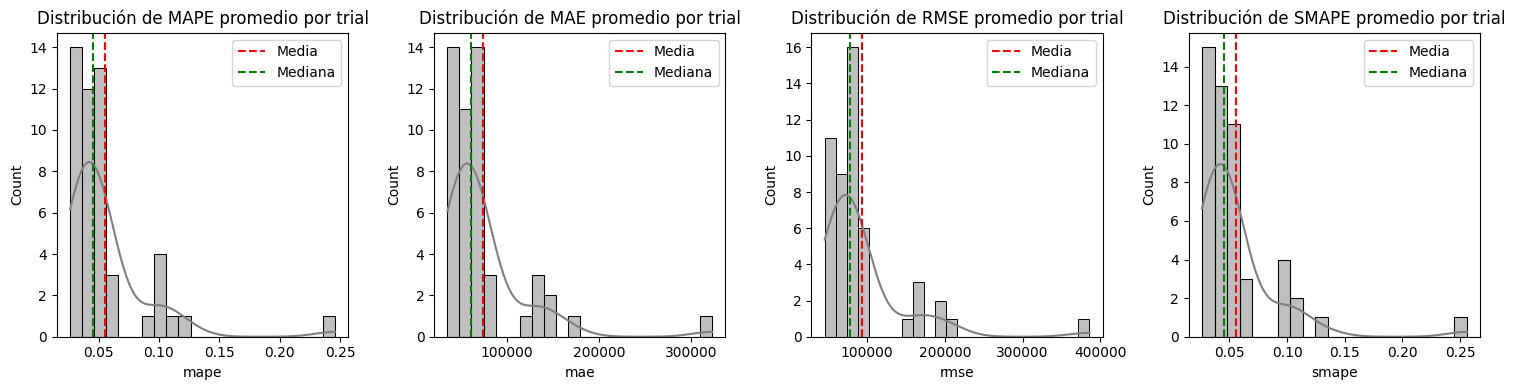

In [15]:
# histograma erorres promedio
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics_avg[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()} promedio por trial")
    ax.axvline(df_metrics_avg[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics_avg[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()

### Distribución de errores por fold y por trial
se muestran los valores de las métricas de error por cada fold y por cada trial

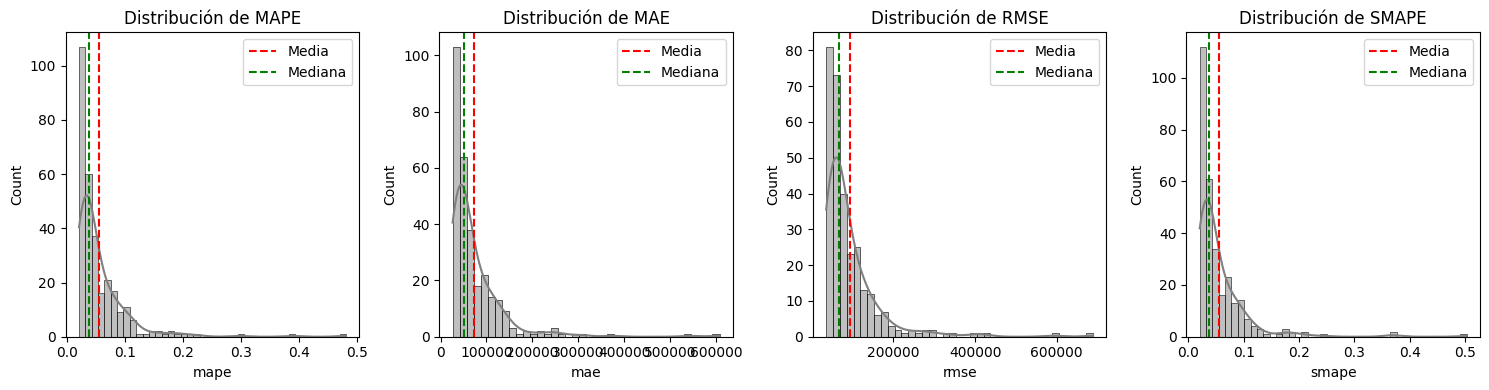

In [16]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


Se ordena por métrica 

In [17]:
# Ordenar por cada métrica para tomar los mejores conjuntos de parametros
df_mape_sorted = df_metrics.sort_values("mape", ascending=True).reset_index(drop=True)
df_mae_sorted = df_metrics.sort_values("mae", ascending=True).reset_index(drop=True)
df_rmse_sorted = df_metrics.sort_values("rmse", ascending=True).reset_index(drop=True)
df_smape_sorted = df_metrics.sort_values("smape", ascending=True).reset_index(drop=True)

print("Mejores Folds por MAPE:")
print(df_mape_sorted.tail())

print("\Mejores Folds por MAE:")
print(df_mae_sorted.tail())

print("\Mejores Folds por RMSE:")
print(df_rmse_sorted.tail())

print("\Mejores Folds por sMAPE:")
print(df_smape_sorted.tail())

Mejores Folds por MAPE:
     trial  fold      mape            mae           rmse     smape
295     12     4  0.214697  299864.545744  327097.948636  0.245896
296     16     1  0.226968  308885.222725  396924.640549  0.213591
297     29     6  0.296063  375128.658390  426845.186862  0.367689
298     29     4  0.389259  542508.700954  590491.521573  0.502667
299     29     5  0.480302  607718.324364  688908.629255  0.369048
\Mejores Folds por MAE:
     trial  fold      mape            mae           rmse     smape
295     12     4  0.214697  299864.545744  327097.948636  0.245896
296     16     1  0.226968  308885.222725  396924.640549  0.213591
297     29     6  0.296063  375128.658390  426845.186862  0.367689
298     29     4  0.389259  542508.700954  590491.521573  0.502667
299     29     5  0.480302  607718.324364  688908.629255  0.369048
\Mejores Folds por RMSE:
     trial  fold      mape            mae           rmse     smape
295     16     1  0.226968  308885.222725  396924.640549

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [18]:
for trial in trials:
    print(trial.user_attrs)

{'fold_1': {'mae': 45601.1357632094, 'mape': 0.032515597894993344, 'rmse': 59521.520068355276, 'smape': 0.033215297479524494}, 'fold_2': {'mae': 32876.26296477495, 'mape': 0.023409555976520165, 'rmse': 46623.90181360306, 'smape': 0.023347243185076177}, 'fold_3': {'mae': 37862.98018591, 'mape': 0.029830090892669664, 'rmse': 53412.80476456779, 'smape': 0.029089088143147503}, 'fold_4': {'mae': 65038.274951076324, 'mape': 0.0464000393556734, 'rmse': 75613.10889441695, 'smape': 0.0476386590160257}, 'fold_5': {'mae': 51857.73458904111, 'mape': 0.04125914426586547, 'rmse': 63545.80939873443, 'smape': 0.04005872841101144}, 'fold_6': {'mae': 34627.63087084148, 'mape': 0.02692898870461004, 'rmse': 43932.02863725532, 'smape': 0.027417945070834646}, 'mape_mean': 0.03339056951505535, 'mae_mean': 44644.003220808874, 'rmse_mean': 57108.19559615547, 'smape_mean': 0.03346116021760333}
{'fold_1': {'mae': 265668.10579745594, 'mape': 0.19629025585176818, 'rmse': 404550.190106658, 'smape': 0.17905140613631

In [19]:
df_trials = {   
    "trial" :[],
    "n_lags": [],
    "n_changepoints": [],
    "learning_rate": [],
    "epochs": [],
    "batch_size": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}


for trial in trials:
    for key in df_trials.keys():

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "mae_mean", "rmse_mean", "smape_mean"]:
            df_trials[key].append(trial.user_attrs[key])

        else: 
            df_trials[key].append(trial.params[key])
   
df_params_models = pd.DataFrame(df_trials)
df_params_models = df_params_models.sort_values("mape_mean") # se ordenan conjuntos de hiperparametros que dejan menor mape promedio y se toma
# el menor
df_params_models.head(5)

,trial,n_lags,n_changepoints,learning_rate,epochs,batch_size,mape_mean,mae_mean,rmse_mean,smape_mean
38,38,12,227,0.015129,123,32,0.026466,35365.381523,45233.112466,0.026288
36,36,12,256,0.028208,135,64,0.026846,35965.750245,48667.125903,0.026754
39,39,12,242,0.012354,124,32,0.026890,36060.654517,49310.971242,0.026640
10,10,1,11,0.009492,105,64,0.027236,36506.971053,49434.771616,0.027197
42,42,12,228,0.023440,113,32,0.028053,37471.203604,50467.791848,0.027886


In [20]:
# se exporta el df con los mejores modelos 
df_params_models.head(3).to_csv("../../../data/best_train_models/best_models_NeuralProphet.csv")

In [21]:
# se fija el modelo 
#metrics = model.fit(folds_data, freq="D")
model = NeuralProphet(**study_np.best_params)
model = model.add_country_holidays(country_name="DE")
model.fit(folds_data, freq="W-MON", progress="off")


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: |          | 0/? [00:44<?, ?it/s, v_num=3946, train_loss=0.014, reg_loss=0.000, MAE=3.21e+4, RMSE=4.29e+4, Loss=0.0139, RegLoss=0.000] 


,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,2.096657,0.0,1.163596e+06,1.318577e+06,2.095923,0.0,0
1,1.715276,0.0,9.659244e+05,1.125194e+06,1.713766,0.0,1
2,1.387079,0.0,7.958518e+05,9.509750e+05,1.386857,0.0,2
3,1.128788,0.0,6.627528e+05,7.984865e+05,1.129827,0.0,3
4,0.921488,0.0,5.524841e+05,6.603204e+05,0.919235,0.0,4
...,...,...,...,...,...,...,...
118,0.013992,0.0,3.195036e+04,4.263929e+04,0.013900,0.0,118
119,0.013986,0.0,3.207700e+04,4.325514e+04,0.013939,0.0,119
120,0.013974,0.0,3.211938e+04,4.322164e+04,0.014004,0.0,120
121,0.013974,0.0,3.219666e+04,4.324420e+04,0.014078,0.0,121


In [22]:
# se hacen predicciones 
#future = model.make_future_dataframe(
#    folds_data,
#    periods=len(val_data),
#    n_historic_predictions=True
#)
#forecast = model.predict(future)

# se extraen predicciones del test
#forecast_test = forecast.iloc[-len(val_data):]

#y_pred = forecast_test["yhat1"].values
y_true = val_data["y"].values

df_combined = pd.concat([folds_data, val_data])
forecast = model.predict(df_combined)
forecast_test = forecast.iloc[-len(val_data):]
y_pred = forecast_test["yhat1"].values

INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 27.83it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [23]:
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true))
smape = smape_fn(y_true, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")


MAE: 34857.24123563217
RMSE: 47320.152375169244
MAPE: 2.7297%
sMAPE: 2.7209%


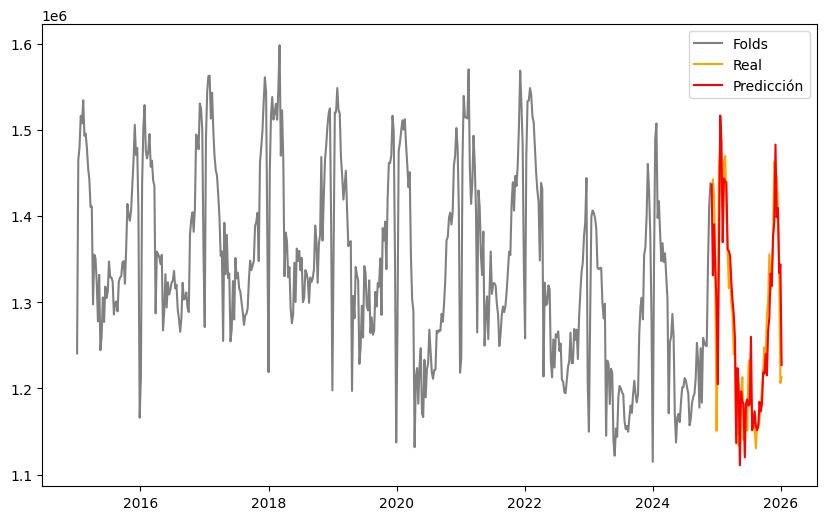

In [24]:
plt.figure(figsize=(10,6))
plt.plot(folds_data["ds"], folds_data["y"], label="Folds", color="gray")
plt.plot(val_data["ds"], y_true, label="Real", color="orange")
plt.plot(val_data["ds"], y_pred, label="Predicción", color="red")
plt.legend()
plt.show()


Se exportan las predicciones en json para poder calcular luego la predicción conjunta

In [25]:
arr_preds = []
for index, value in enumerate(df_data_close[folds_data_size:]["ds"]):
    dict_pred = {
        "Date": value.strftime("%Y-%m-%d"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2024-12-02', 'pred': 1436608.25},
 {'Date': '2024-12-09', 'pred': 1331192.25},
 {'Date': '2024-12-16', 'pred': 1390406.375},
 {'Date': '2024-12-23', 'pred': 1337323.0},
 {'Date': '2024-12-30', 'pred': 1298702.875},
 {'Date': '2025-01-06', 'pred': 1204749.25},
 {'Date': '2025-01-13', 'pred': 1370422.125},
 {'Date': '2025-01-20', 'pred': 1516576.25},
 {'Date': '2025-01-27', 'pred': 1485909.25},
 {'Date': '2025-02-03', 'pred': 1369616.125},
 {'Date': '2025-02-10', 'pred': 1443734.75},
 {'Date': '2025-02-17', 'pred': 1439647.5},
 {'Date': '2025-02-24', 'pred': 1438928.875},
 {'Date': '2025-03-03', 'pred': 1360988.375},
 {'Date': '2025-03-10', 'pred': 1359486.625},
 {'Date': '2025-03-17', 'pred': 1353641.5},
 {'Date': '2025-03-24', 'pred': 1324002.25},
 {'Date': '2025-03-31', 'pred': 1302133.0},
 {'Date': '2025-04-07', 'pred': 1286279.75},
 {'Date': '2025-04-14', 'pred': 1258058.625},
 {'Date': '2025-04-21', 'pred': 1136497.125},
 {'Date': '2025-04-28', 'pred': 1223564.75},
 {'Da

In [26]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape),
    "mae_val": float(mae),
    "smape_val": float(smape),
    "rmse_val": float(rmse),
    "predictions": arr_preds
}
with open ("../../../data/preds_energy_models/neuralprophet_preds.json", "w") as json_file:
    json.dump(dict_to_export, json_file, indent=4)

validacion adicional: se ejecuta varias veces el modelo final y se generan las predicciones con el fin de validar que los rangos de variación de las métricas de error sean consistentes

In [27]:
# se fija el modelo a los datos de folds
n_iters = 10 # cantidad de veces en las que se instancia el modelo 
preds_dict = []

for i in range(n_iters):
    model = NeuralProphet(**study_np.best_params)
    model = model.add_country_holidays(country_name="DE")
    model.fit(folds_data, freq="W-MON", progress="off")
    
    y_true = val_data["y"].values

    df_combined = pd.concat([folds_data, val_data])
    forecast = model.predict(df_combined)
    forecast_test = forecast.iloc[-len(val_data):]
    y_pred = forecast_test["yhat1"].values

    # métricas de error
    smape_fn = MeanAbsolutePercentageError(symmetric=True)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    smape = smape_fn(y_true, y_pred)

    preds_dict.append({
        "iteracion": i,
        "mape": mape * 100,
        "rmse": rmse,
        "mae": mae,
        "smape": smape * 100,
        "preds": y_pred
    })

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: |          | 0/? [00:39<?, ?it/s, v_num=3947, train_loss=0.0133, reg_loss=0.000, MAE=2.98e+4, RMSE=4.19e+4, Loss=0.0132, RegLoss=0.000]

INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 25.85it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


...

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.807% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: |          | 0/? [00:48<?, ?it/s, v_num=3956, train_loss=0.0109, reg_loss=0.000, MAE=2.81e+4, RMSE=3.81e+4, Loss=0.011, RegLoss=0.000] 

INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 18.39it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [28]:
cols_df_preds = ["iteracion", "mape", "rmse", "mae", "smape"]
arr_iteracion = [el["iteracion"] for el in preds_dict]
mape_iteracion = [el["mape"] for el in preds_dict]
mae_iteracion = [el["mae"] for el in preds_dict]
rmse_iteracion = [el["rmse"] for el in preds_dict]
smape_iteracion = [el["smape"] for el in preds_dict]


dataframe = pd.DataFrame(columns=cols_df_preds )
dataframe["iteracion"] = arr_iteracion
dataframe["mape"] = mape_iteracion
dataframe["mae"] = mae_iteracion
dataframe["rmse"] = rmse_iteracion
dataframe["smape"] = smape_iteracion
dataframe

,iteracion,mape,rmse,mae,smape
0,0,2.625927,44863.977102,33384.165780,2.604770
1,1,2.604345,45846.222605,32870.535029,2.578164
2,2,2.378710,42242.181526,30195.868428,2.363252
3,3,2.428016,43784.322186,30893.693637,2.414096
4,4,2.534239,44258.019682,32235.652911,2.522547
5,5,2.570944,43809.638385,32904.595521,2.561564
6,6,2.851441,47539.787365,36171.739351,2.831873
7,7,2.428047,43235.138483,30951.413859,2.411791
8,8,2.394801,41493.178441,30301.338773,2.381464
9,9,2.533993,44327.309500,32211.975374,2.526259
